# ________________________________WALMART PROJECT ____________________________

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df = pd.read_csv('Walmart DataSet.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Check Dataset

In [3]:
df.shape

(6435, 8)

# Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum().sum()

np.int64(0)

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [8]:
df.dtypes

,0
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


# Statistical Analysis

In [10]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


# Sales Distributation  

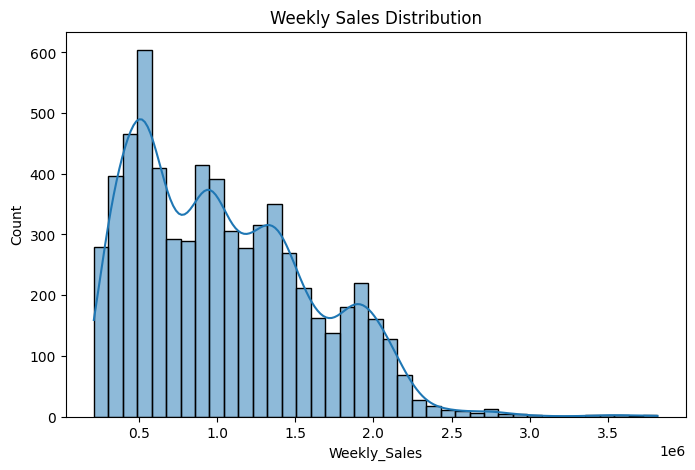

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Weekly_Sales"], kde=True)
plt.title("Weekly Sales Distribution")
plt.show()

# Outlier Analysis

# Weekly Sales outlier:

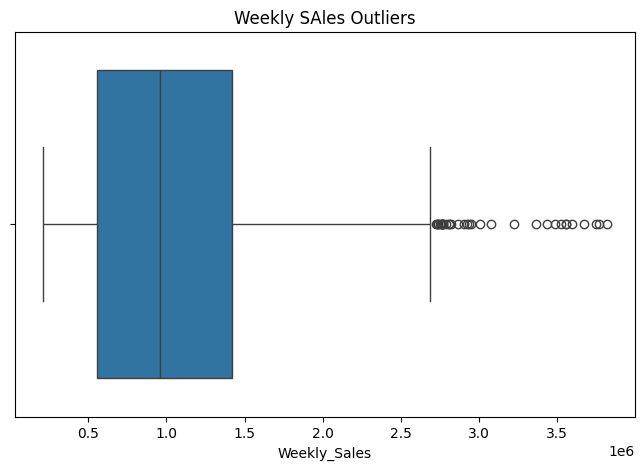

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Weekly_Sales'])
plt.title("Weekly SAles Outliers")
plt.show()

# IQR method:

In [13]:
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)

IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.3*IQR

outliers = df[(df['Weekly_Sales']<lower) | (df['Weekly_Sales']>upper)]

outliers.shape

(48, 8)

# 1. You are provided with the weekly sales data for their various outlets. Use statistical analysis, EDA, outlier analysis, and handle the missing values to come up with various insights that can give them a clear perspective on the following:

# a. If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?
# b. If the weekly sales show a seasonal trend, when and what could be the reason?
# c. Does temperature affect the weekly sales in any manner?
# d. How is the Consumer Price index affecting the weekly sales of various stores?
# e. Top performing stores according to the historical data.
# f. The worst performing store, and how significant is the difference between the highest and lowest performing stores

# Q1.(a) ANS --

# Correlation

In [14]:
df[['Weekly_Sales','Unemployment']].corr()

,Weekly_Sales,Unemployment
Weekly_Sales,1.000000,-0.106176
Unemployment,-0.106176,1.000000


# Visualization:

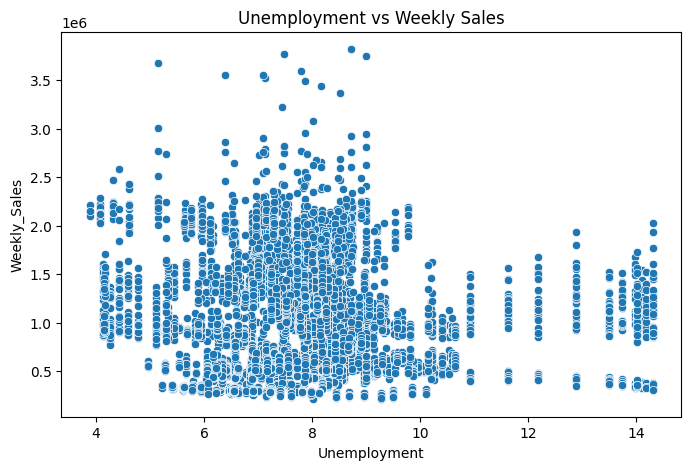

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Unemployment',
    y='Weekly_Sales'
)
plt.title("Unemployment vs Weekly Sales")
plt.show()

# Store Wise

In [16]:
store_unemployment=df.groupby('Store')['Unemployment'].mean()

store_unemployment.sort_values(ascending=False).head()

,Unemployment
Store,
12,13.116483
38,13.116483
28,13.116483
43,9.934804
34,9.934804


# Sales affected stores:

In [17]:
store_sales=df.groupby('Store')['Weekly_Sales'].mean()

result=pd.DataFrame({
    'Sales':store_sales,
    'Unemployment':store_unemployment
})

result.sort_values(
    by='Unemployment',
    ascending=False
).head()

,Sales,Unemployment
Store,,
12,1.009002e+06,13.116483
38,3.857317e+05,13.116483
28,1.323522e+06,13.116483
43,6.333247e+05,9.934804
34,9.667816e+05,9.934804


# b. Ans ---
# Seasonl Trend

In [18]:
df['Month'] = df["Date"].dt.month

# Monthly sales:

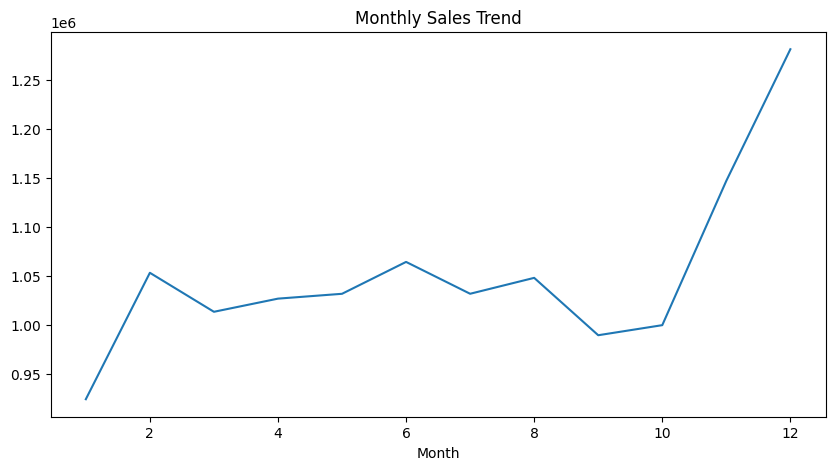

In [19]:
monthly_sales=df.groupby('Month')['Weekly_Sales'].mean()

monthly_sales.plot(
    kind='line',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.show()

# Year Wise:

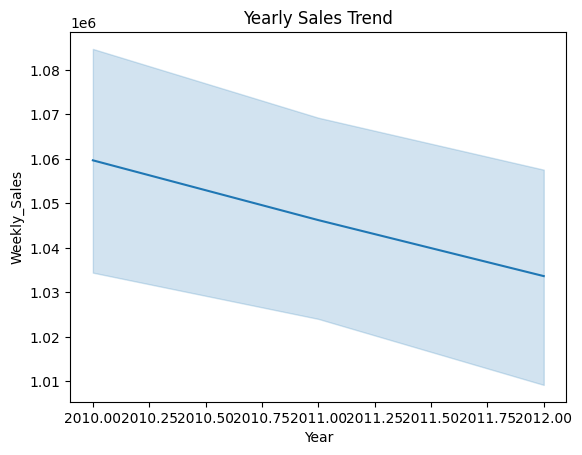

In [20]:
df['Year']=df['Date'].dt.year

sns.lineplot(
    data=df,
    x='Year',
    y='Weekly_Sales'
)

plt.title("Yearly Sales Trend")
plt.show()

# (C) ans --

# Temperature effect

In [21]:
df[['Temperature', 'Weekly_Sales']].corr()

,Temperature,Weekly_Sales
Temperature,1.00000,-0.06381
Weekly_Sales,-0.06381,1.00000


# Graph

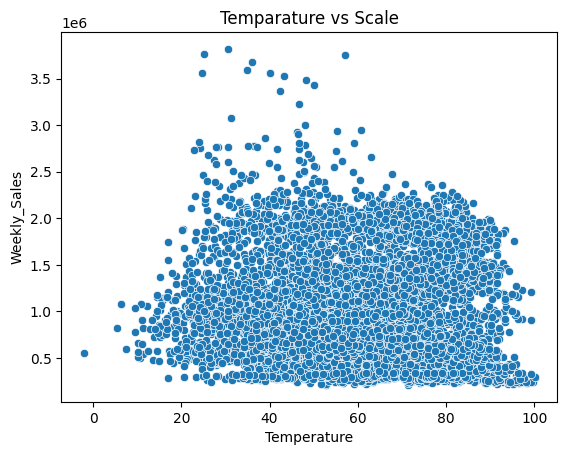

In [22]:
sns.scatterplot (
             data = df,
             x = 'Temperature',
             y = 'Weekly_Sales'
)
plt.title("Temparature vs Scale")
plt.show()

# (d) ans --

# CPI effect

In [23]:
df[['CPI', 'Weekly_Sales']].corr()

,CPI,Weekly_Sales
CPI,1.000000,-0.072634
Weekly_Sales,-0.072634,1.000000


# (e) ans --

# Top Performing Stores

In [24]:
top_store=df.groupby('Store') ['Weekly_Sales'].sum()

top_store.sort_values(
     ascending=False
).head(10)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


# Visulization:

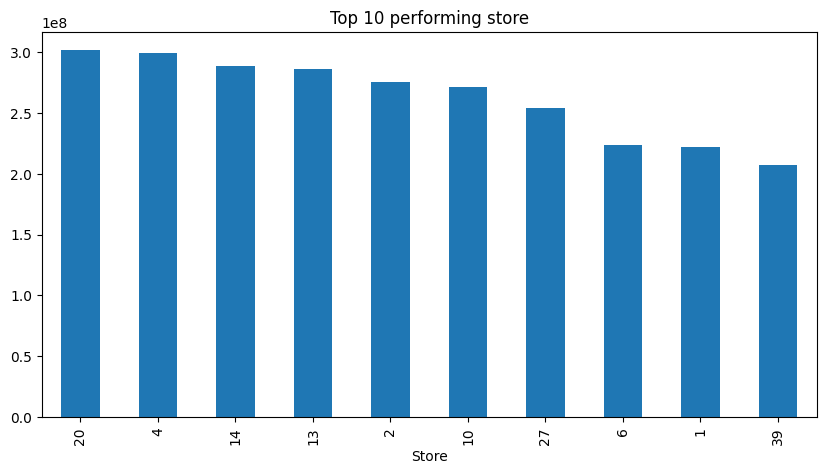

In [25]:
top_store.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 performing store")
plt.show()

# (f) ans --

# Worst Performing Store

In [26]:
top_store.sort_values().head()

,Weekly_Sales
Store,
33,37160221.96
44,43293087.84
5,45475688.90
36,53412214.97
38,55159626.42


# Difference

In [27]:
highest = top_store.max()
lowest = top_store.min()

difference = highest-lowest

difference

264237570.49999997

# 2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks

In [28]:
from statsmodels.tsa.arima.model import ARIMA

In [29]:
forecast_dict = {}

for store in  df['Store'].unique():

    store_df = df[df['Store'] == store].sort_values('Date')

    sales = store_df.set_index('Date')['Weekly_Sales']

    model = ARIMA(sales, order=(5,1,0))

    model_fit = model.fit()

    forecast = model_fit.forecast(steps= 12)

    forecast_dict[store] = forecast

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  

In [30]:
print(forecast)

2012-11-02    750791.399195
2012-11-09    745211.571079
2012-11-16    739952.664607
2012-11-23    750432.961269
2012-11-30    741484.306474
2012-12-07    744667.652629
2012-12-14    743911.993265
2012-12-21    746772.843026
2012-12-28    742995.639142
2013-01-04    745551.959243
2013-01-11    744315.335515
2013-01-18    745265.967523
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [31]:
forecast_dict[1]

,predicted_mean
2012-11-02,1.565441e+06
2012-11-09,1.524021e+06
2012-11-16,1.530963e+06
2012-11-23,1.530657e+06
2012-11-30,1.545705e+06
2012-12-07,1.526392e+06
2012-12-14,1.534726e+06
2012-12-21,1.532667e+06
2012-12-28,1.536849e+06
2013-01-04,1.530657e+06


In [32]:
for store, forecast in  forecast_dict.items():
    print(f"\nStore {store}")
    print(forecast)


Store 1
2012-11-02    1.565441e+06
2012-11-09    1.524021e+06
2012-11-16    1.530963e+06
2012-11-23    1.530657e+06
2012-11-30    1.545705e+06
2012-12-07    1.526392e+06
2012-12-14    1.534726e+06
2012-12-21    1.532667e+06
2012-12-28    1.536849e+06
2013-01-04    1.530657e+06
2013-01-11    1.535251e+06
2013-01-18    1.533146e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64

Store 2
2012-11-02    1.899547e+06
2012-11-09    1.857345e+06
2012-11-16    1.866606e+06
2012-11-23    1.864091e+06
2012-11-30    1.878495e+06
2012-12-07    1.861834e+06
2012-12-14    1.869946e+06
2012-12-21    1.866690e+06
2012-12-28    1.870910e+06
2013-01-04    1.865635e+06
2013-01-11    1.869594e+06
2013-01-18    1.867425e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64

Store 3
2012-11-02    417147.557313
2012-11-09    407335.611425
2012-11-16    414480.098637
2012-11-23    410428.241330
2012-11-30    414165.516500
2012-12-07    411217.828566
2012-12-14    413377.632597
2012-12-21    411850.794560
2

# Forecast Graph

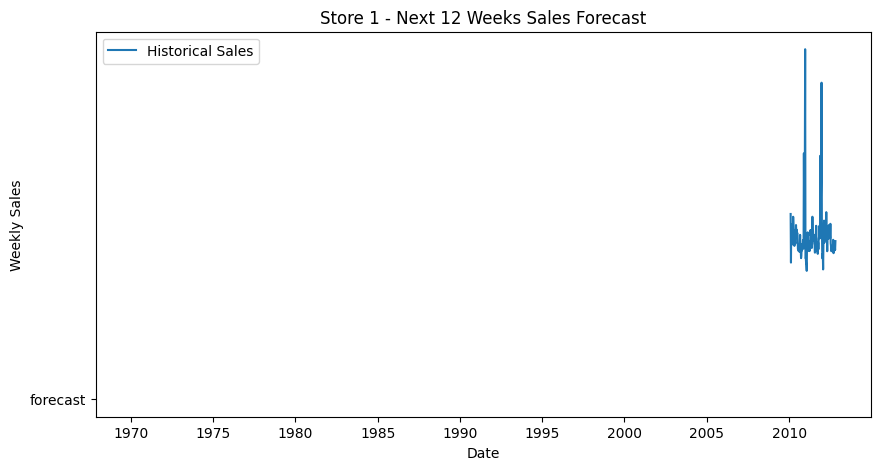

In [33]:
plt.figure(figsize=(10,5))
plt.plot(sales, label='Historical Sales')
plt.plot('forecast', color='red')
plt.title('Store 1 - Next 12 Weeks Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.show()

## **Self Practice  Internship Regarding **

In [34]:
store_data = df.groupby('Store').agg(
    Total_Sales=('Weekly_Sales', 'sum'),
    Average_Sales=('Weekly_Sales', 'mean'),
    Sales_Std=('Weekly_Sales', 'std'),
    Avg_Temperature=('Temperature', 'mean'),
    Avg_Fuel_Price=('Fuel_Price', 'mean'),
    Avg_CPI=('CPI', 'mean'),
    Avg_Unemployment=('Unemployment', 'mean'),
    Holiday_Frequency=('Holiday_Flag', 'mean')
).reset_index()

print(store_data.head())
print("Number of stores:", store_data['Store'].nunique())

   Store   Total_Sales  Average_Sales      Sales_Std  Avg_Temperature  \
0      1  2.224028e+08   1.555264e+06  155980.767761        68.306783   
1      2  2.753824e+08   1.925751e+06  237683.694682        68.216364   
2      3  5.758674e+07   4.027044e+05   46319.631557        71.434196   
3      4  2.995440e+08   2.094713e+06  266201.442297        62.253357   
4      5  4.547569e+07   3.180118e+05   37737.965745        69.410140   

   Avg_Fuel_Price     Avg_CPI  Avg_Unemployment  Holiday_Frequency  
0        3.219699  215.996892          7.610420            0.06993  
1        3.219699  215.646311          7.623846            0.06993  
2        3.219699  219.391531          7.176986            0.06993  
3        3.216972  128.679669          5.964692            0.06993  
4        3.219699  216.565581          6.295406            0.06993  
Number of stores: 45


In [35]:
from sklearn.preprocessing import StandardScaler

features = [
    'Total_Sales',
    'Average_Sales',
    'Sales_Std',
    'Avg_Temperature',
    'Avg_Fuel_Price',
    'Avg_CPI',
    'Avg_Unemployment',
    'Holiday_Frequency'
]

X = store_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (45, 8)
Scaled shape: (45, 8)


In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: {value:.2f}")

Inertia values:
K = 2: 220.33
K = 3: 163.94
K = 4: 126.09
K = 5: 99.52
K = 6: 86.03
K = 7: 74.30
K = 8: 66.09
K = 9: 58.20
K = 10: 53.81


# **Elbow Method**

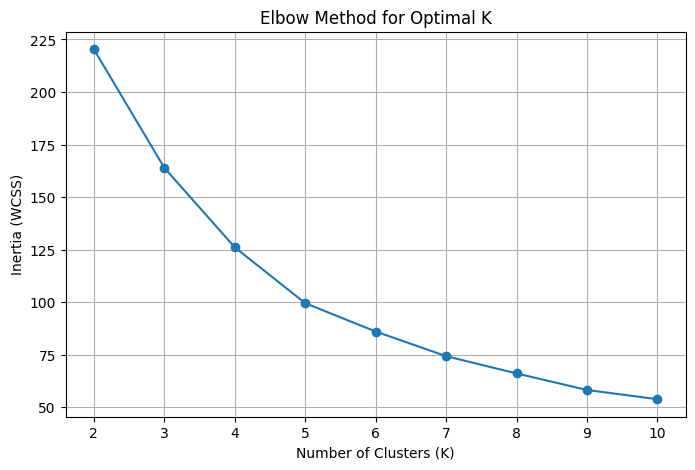

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### **Silhoutte**




In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: {score:.4f}")

Silhouette Scores:
K = 2: 0.2620
K = 3: 0.2728
K = 4: 0.3245
K = 5: 0.3412
K = 6: 0.3240
K = 7: 0.3405
K = 8: 0.3419
K = 9: 0.3455
K = 10: 0.3551


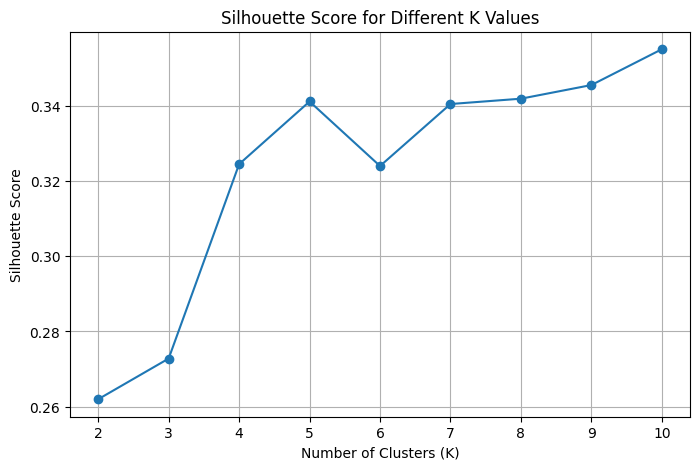

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [40]:
from sklearn.cluster import KMeans

final_k = 3

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

store_data['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(store_data[['Store', 'Cluster']].head(10))
print("\nCluster Counts:")
print(store_data['Cluster'].value_counts().sort_index())

   Store  Cluster
0      1        1
1      2        1
2      3        0
3      4        1
4      5        0
5      6        1
6      7        0
7      8        0
8      9        0
9     10        1

Cluster Counts:
Cluster
0    14
1    14
2    17
Name: count, dtype: int64


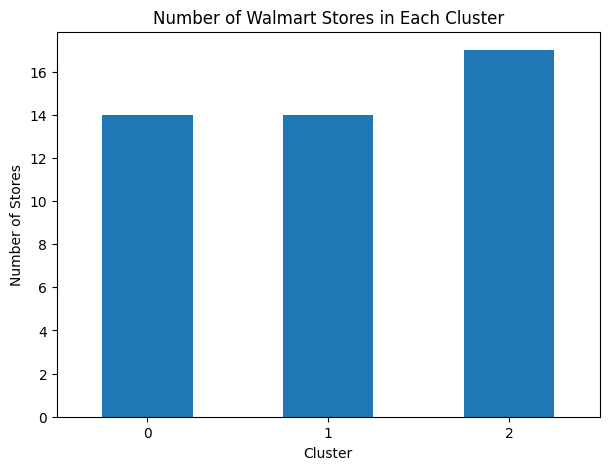

In [41]:
plt.figure(figsize=(7, 5))

store_data['Cluster'].value_counts().sort_index().plot(
    kind='bar'
)

plt.xlabel('Cluster')
plt.ylabel('Number of Stores')
plt.title('Number of Walmart Stores in Each Cluster')
plt.xticks(rotation=0)
plt.show()

In [42]:
from sklearn.cluster import KMeans

final_k = 5

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

store_data['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(store_data[['Store', 'Cluster']].head(10))

print("\nCluster Counts:")
print(store_data['Cluster'].value_counts().sort_index())

   Store  Cluster
0      1        2
1      2        2
2      3        0
3      4        4
4      5        0
5      6        2
6      7        1
7      8        0
8      9        0
9     10        4

Cluster Counts:
Cluster
0     9
1    17
2     6
3     5
4     8
Name: count, dtype: int64


In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = store_data['Cluster']

print(pca_df.head())

        PC1       PC2  Cluster
0  0.759376 -1.658491        2
1  2.097692 -1.858980        2
2 -2.432295 -1.281061        0
3  3.110646 -1.053570        4
4 -2.601736 -1.415963        0


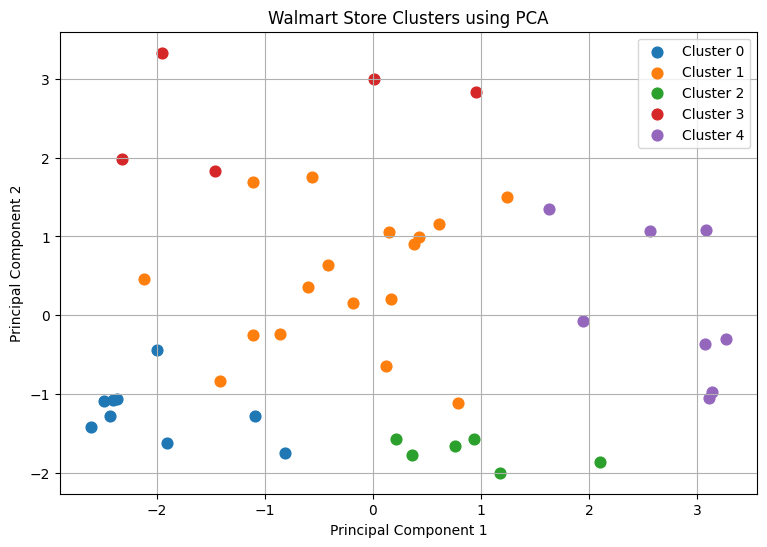

In [44]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        s=60
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Walmart Store Clusters using PCA')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
cluster_summary = store_data.groupby('Cluster')[features].mean().round(2)

print(cluster_summary)

          Total_Sales  Average_Sales  Sales_Std  Avg_Temperature  \
Cluster                                                            
0        7.775755e+07      543759.11   59343.40            68.89   
1        1.236519e+08      864698.65  127938.53            51.30   
2        2.204273e+08     1541449.44  185891.10            69.69   
3        1.010873e+08      706904.21   87617.97            71.95   
4        2.634148e+08     1842061.60  263610.23            57.48   

         Avg_Fuel_Price  Avg_CPI  Avg_Unemployment  Holiday_Frequency  
Cluster                                                                
0                  3.22   215.95              7.40               0.07  
1                  3.37   155.56              7.91               0.07  
2                  3.22   216.49              7.42               0.07  
3                  3.59   128.68             11.25               0.07  
4                  3.44   148.82              7.27               0.07  


In [46]:
cluster_summary = store_data.groupby('Cluster').agg(
    Store_Count=('Store', 'count'),
    Total_Sales=('Total_Sales', 'mean'),
    Average_Sales=('Average_Sales', 'mean'),
    Sales_Std=('Sales_Std', 'mean'),
    Avg_Temperature=('Avg_Temperature', 'mean'),
    Avg_Fuel_Price=('Avg_Fuel_Price', 'mean'),
    Avg_CPI=('Avg_CPI', 'mean'),
    Avg_Unemployment=('Avg_Unemployment', 'mean'),
    Holiday_Frequency=('Holiday_Frequency', 'mean')
).round(2)

print(cluster_summary)

         Store_Count   Total_Sales  Average_Sales  Sales_Std  Avg_Temperature  \
Cluster                                                                         
0                  9  7.775755e+07      543759.11   59343.40            68.89   
1                 17  1.236519e+08      864698.65  127938.53            51.30   
2                  6  2.204273e+08     1541449.44  185891.10            69.69   
3                  5  1.010873e+08      706904.21   87617.97            71.95   
4                  8  2.634148e+08     1842061.60  263610.23            57.48   

         Avg_Fuel_Price  Avg_CPI  Avg_Unemployment  Holiday_Frequency  
Cluster                                                                
0                  3.22   215.95              7.40               0.07  
1                  3.37   155.56              7.91               0.07  
2                  3.22   216.49              7.42               0.07  
3                  3.59   128.68             11.25               0.07  


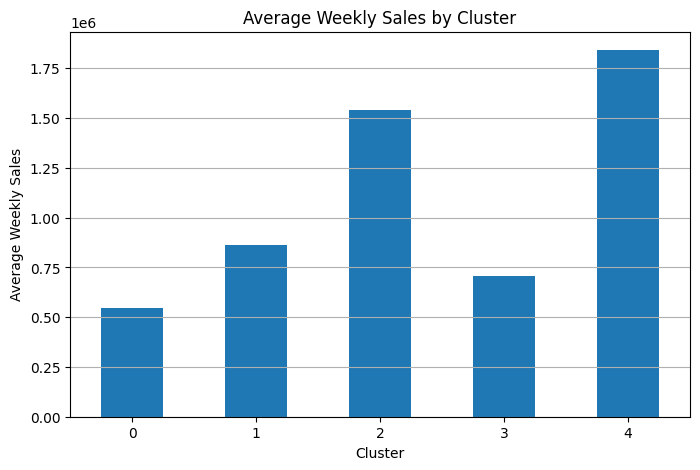

In [47]:
plt.figure(figsize=(8, 5))

cluster_summary['Average_Sales'].plot(
    kind='bar'
)
plt.xlabel('Cluster')
plt.ylabel('Average Weekly Sales')
plt.title('Average Weekly Sales by Cluster')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [48]:
print(cluster_summary)

         Store_Count   Total_Sales  Average_Sales  Sales_Std  Avg_Temperature  \
Cluster                                                                         
0                  9  7.775755e+07      543759.11   59343.40            68.89   
1                 17  1.236519e+08      864698.65  127938.53            51.30   
2                  6  2.204273e+08     1541449.44  185891.10            69.69   
3                  5  1.010873e+08      706904.21   87617.97            71.95   
4                  8  2.634148e+08     1842061.60  263610.23            57.48   

         Avg_Fuel_Price  Avg_CPI  Avg_Unemployment  Holiday_Frequency  
Cluster                                                                
0                  3.22   215.95              7.40               0.07  
1                  3.37   155.56              7.91               0.07  
2                  3.22   216.49              7.42               0.07  
3                  3.59   128.68             11.25               0.07  


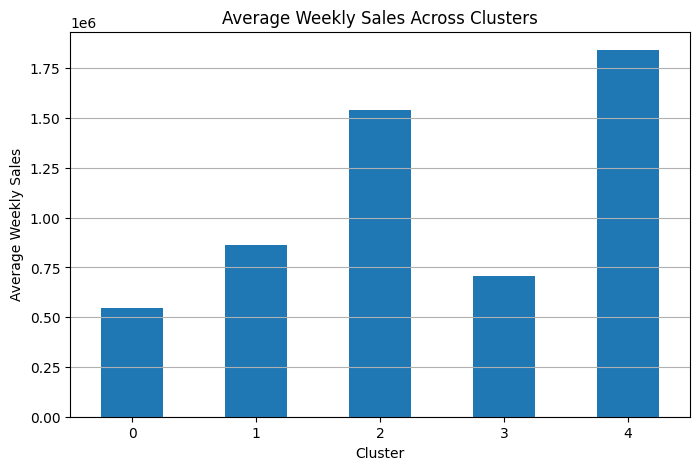

In [49]:
plt.figure(figsize=(8,5))

cluster_summary['Average_Sales'].plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Average Weekly Sales')
plt.title('Average Weekly Sales Across Clusters')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Crete Date - Based Features

In [50]:
# Extract useful information from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

# Display new features
print(df[['Date', 'Year', 'Month', 'Week']].head())

        Date  Year  Month  Week
0 2010-02-05  2010      2     5
1 2010-02-12  2010      2     6
2 2010-02-19  2010      2     7
3 2010-02-26  2010      2     8
4 2010-03-05  2010      3     9


Feature & Target

In [51]:
features = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Year',
    'Month',
    'Week'
]

X = df[features]
y = df['Weekly_Sales']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (6435, 9)
Target shape: (6435,)


Weekly Sales Distribution

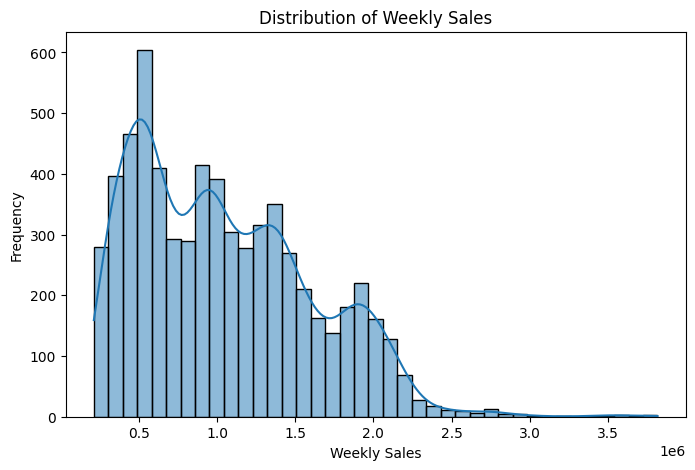

In [52]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Weekly_Sales'], kde=True)

plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()

	Average Weekly Sales by Store

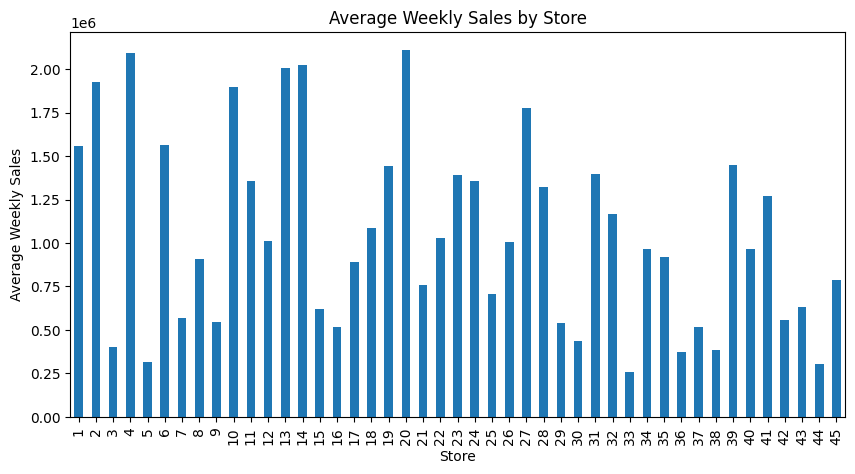

In [53]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean()

plt.figure(figsize=(10, 5))

store_sales.plot(kind='bar')

plt.title('Average Weekly Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.show()

	Correlation Analysis

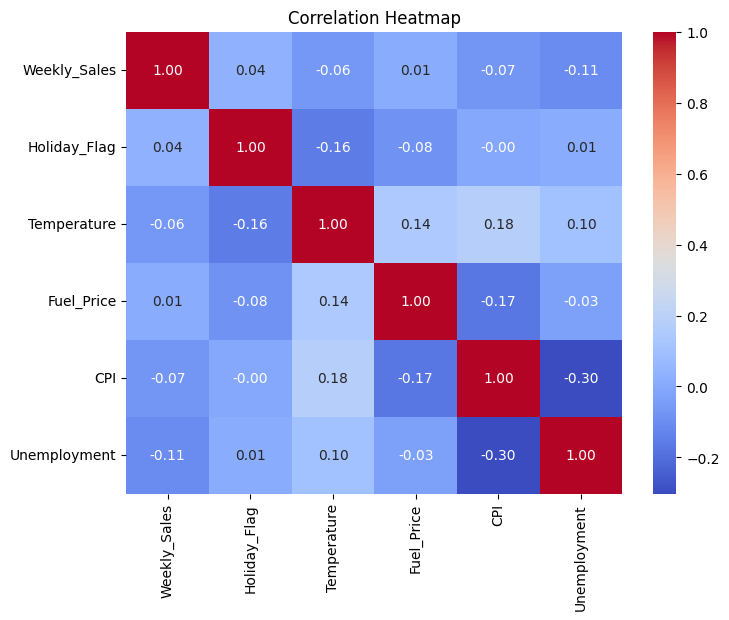

In [54]:
corr_columns = [
    'Weekly_Sales',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[corr_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

Train Test Split  

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5148, 9)
Testing features: (1287, 9)
Training target: (5148,)
Testing target: (1287,)


Linear Regression

In [56]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Random Forest Regression

In [57]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


## **Cross Validation **

In [58]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Linear Regression
linear_cv = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

# 5-fold cross-validation for Random Forest
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Linear Regression CV R² Scores:", linear_cv)
print("Linear Regression Mean CV R²:", linear_cv.mean())

print("\nRandom Forest CV R² Scores:", rf_cv)
print("Random Forest Mean CV R²:", rf_cv.mean())

Linear Regression CV R² Scores: [0.16038635 0.12531314 0.13729659 0.13682581 0.16260901]
Linear Regression Mean CV R²: 0.14448617711530545

Random Forest CV R² Scores: [0.94396593 0.95730447 0.95907147 0.96110167 0.96592243]
Random Forest Mean CV R²: 0.957473192360782


# **Model Evalution**

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

# Random Forest metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²   :", r2_linear)

print("\nRandom Forest Regression")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²   :", r2_rf)

Linear Regression
MAE : 432594.97688780195
MSE : 272049348139.45193
RMSE: 521583.50063959265
R²   : 0.15553160499602847

Random Forest Regression
MAE : 62022.51483061383
MSE : 13020256696.914726
RMSE: 114106.3394247433
R²   : 0.9595838205436641


# **Model Comparision **

In [62]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [mae_linear, mae_rf],
    'MSE': [mse_linear, mse_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R2 Score': [r2_linear, r2_rf]
})

print(comparison.round(2))

                      Model        MAE           MSE       RMSE  R2 Score
0         Linear Regression  432594.98  2.720493e+11  521583.50      0.16
1  Random Forest Regression   62022.51  1.302026e+10  114106.34      0.96


# Feature Importance & Result

In [63]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

        Feature  Importance
0         Store    0.663337
4           CPI    0.153930
5  Unemployment    0.104181
8          Week    0.050030
2   Temperature    0.012892
3    Fuel_Price    0.010295
7         Month    0.002867
1  Holiday_Flag    0.001594
6          Year    0.000874


# **Visualization**

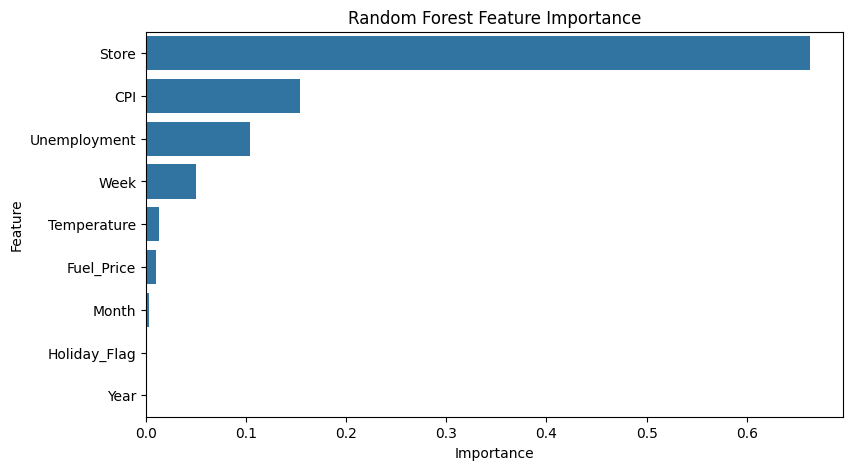

In [61]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()